# Évaluation du Prediction Engine (Isolation Forest) sur données réelles — PSM

**Dataset** : Pooled Server Metrics (PSM), collecté par eBay sur plusieurs nœuds de serveurs applicatifs.
Source : [eBay/RANSynCoders](https://github.com/eBay/RANSynCoders/tree/main/data)

- `train.csv` : 132 481 lignes, comportement **normal uniquement** (13 semaines)
- `test.csv` : 87 841 lignes (8 semaines), comportement mixte normal/anormal
- `test_label.csv` : labels réels d'anomalie (0 = normal, 1 = anomalie), déterminés par les équipes eBay

Les 25 colonnes de métriques (`feature_0` à `feature_24`) sont anonymisées et déjà normalisées entre 0 et 1
par eBay pour des raisons de confidentialité (métriques de performance serveur : CPU, mémoire, réseau, etc.).

**Objectif** : entraîner l'Isolation Forest utilisée par le `prediction-engine` sur ces vraies données de
production, et l'évaluer rigoureusement (précision, rappel, F1, taux de faux positifs, ROC-AUC) grâce aux
labels réels — ce que le cahier des charges du PFA demande explicitement pour le module central du projet.

> Ce notebook est une évaluation scientifique indépendante. La démo live de la plateforme (dashboard,
> RCA, auto-healing) continue de fonctionner avec ses propres métriques simulées nommées
> (`cpu_usage`, `memory_usage`, ...) et n'est pas modifiée par ce travail.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Chargement des données

In [2]:
DATA_DIR = "../data/psm"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")
test_label_df = pd.read_csv(f"{DATA_DIR}/test_label.csv")

feature_cols = [c for c in train_df.columns if c.startswith("feature_")]

print(f"train.csv       : {train_df.shape[0]:>7} lignes x {train_df.shape[1]} colonnes")
print(f"test.csv        : {test_df.shape[0]:>7} lignes x {test_df.shape[1]} colonnes")
print(f"test_label.csv  : {test_label_df.shape[0]:>7} lignes")
print(f"Nombre de features : {len(feature_cols)}")
train_df.head()

train.csv       :  132481 lignes x 26 colonnes
test.csv        :   87841 lignes x 26 colonnes
test_label.csv  :   87841 lignes
Nombre de features : 25


,timestamp_(min),feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
0,0.0,0.732689,0.761748,0.606848,0.488746,0.424310,0.403609,0.519318,0.398792,0.451453,...,0.318797,0.451856,0.571500,0.469717,0.609883,0.008432,0.0,0.481838,0.006536,0.138249
1,1.0,0.732799,0.761855,0.607133,0.488781,0.432008,0.410256,0.511364,0.402568,0.455657,...,0.321463,0.456123,0.562226,0.466533,0.629812,0.008432,0.0,0.477218,0.006536,0.115207
2,2.0,0.732938,0.761594,0.606895,0.488791,0.418858,0.407724,0.488636,0.396526,0.456104,...,0.347219,0.456692,0.572002,0.487845,0.643598,0.006745,0.0,0.492623,0.008715,0.092166
3,3.0,0.732893,0.761656,0.606478,0.488802,0.417896,0.404242,0.500000,0.405589,0.460020,...,0.361904,0.460532,0.563354,0.479512,0.644690,0.008432,0.0,0.457064,0.008715,0.142857
4,4.0,0.732788,0.761573,0.606777,0.488800,0.421103,0.407407,0.511364,0.399547,0.458507,...,0.359767,0.458825,0.563354,0.448298,0.629948,0.006745,0.0,0.472223,0.006536,0.170507


## 2. Exploration rapide (EDA)

In [3]:
print("Valeurs manquantes (train) :", train_df[feature_cols].isna().sum().sum())
print("Valeurs manquantes (test)  :", test_df[feature_cols].isna().sum().sum())

# Les NaN éventuels sont remplacés par la médiane de la colonne (comportement normal supposé)
train_df[feature_cols] = train_df[feature_cols].fillna(train_df[feature_cols].median())
test_df[feature_cols] = test_df[feature_cols].fillna(test_df[feature_cols].median())

train_df[feature_cols].describe().T[["mean", "std", "min", "max"]]

Valeurs manquantes (train) : 4195
Valeurs manquantes (test)  : 0


,mean,std,min,max
feature_0,0.835810,0.067326,0.486490,1.000000
feature_1,0.840205,0.039472,0.525682,0.909956
feature_2,0.634216,0.102920,0.421484,1.000000
feature_3,0.575081,0.049675,0.380874,0.676682
feature_4,0.543317,0.089370,0.065106,0.929442
feature_5,0.511745,0.077698,0.110161,0.877493
feature_6,0.549228,0.063959,0.215909,1.000000
feature_7,0.537704,0.090104,0.077795,0.968278
feature_8,0.551134,0.078982,0.038693,0.935128
feature_9,0.545177,0.081033,0.040358,0.915990


Taux d'anomalies réel dans test.csv : 27.76%


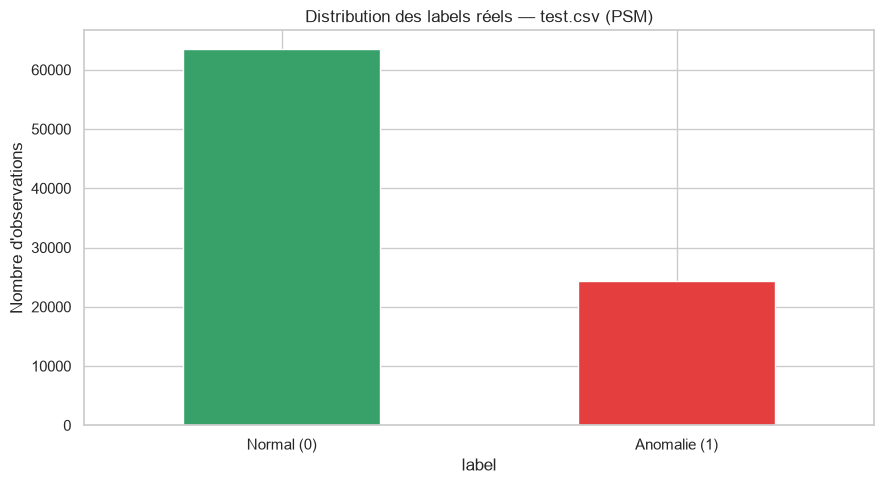

In [4]:
anomaly_rate = test_label_df["label"].mean()
print(f"Taux d'anomalies réel dans test.csv : {anomaly_rate:.2%}")

ax = test_label_df["label"].value_counts().sort_index().plot(
    kind="bar", color=["#38a169", "#e53e3e"]
)
ax.set_xticklabels(["Normal (0)", "Anomalie (1)"], rotation=0)
ax.set_title("Distribution des labels réels — test.csv (PSM)")
ax.set_ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

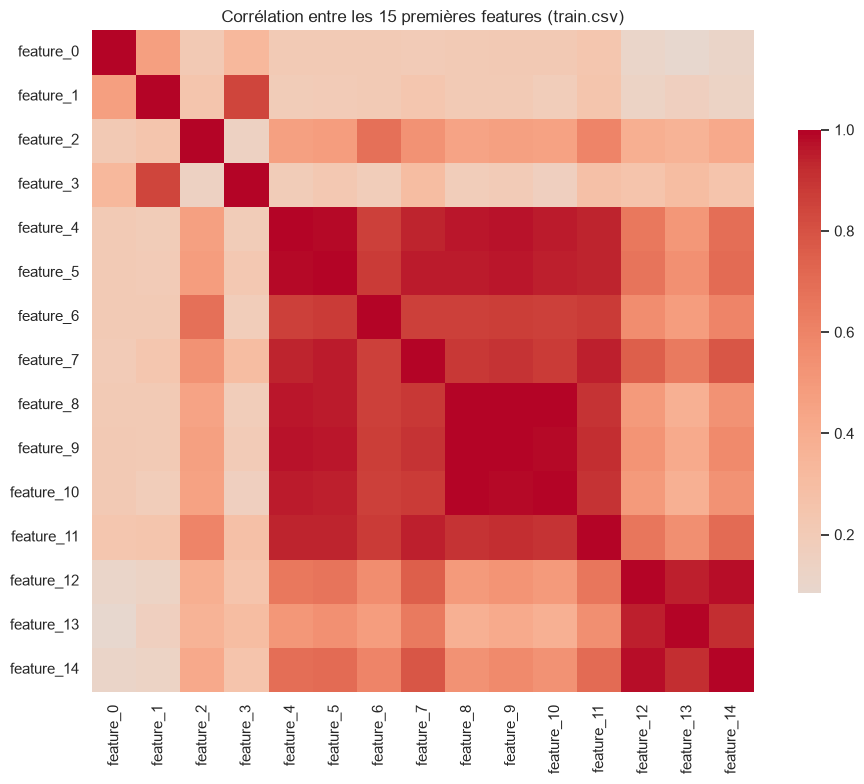

In [5]:
corr = train_df[feature_cols[:15]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .7})
plt.title("Corrélation entre les 15 premières features (train.csv)")
plt.tight_layout()
plt.show()

## 3. Entraînement du modèle Isolation Forest

Même configuration que le `prediction-engine` en production (`app/services/prediction_service.py`) :
`n_estimators=100`, `contamination=0.05`, `random_state=42`. Le modèle est entraîné **uniquement sur
train.csv** (données normales), comme dans la vraie logique métier — l'Isolation Forest apprend ce qu'est
un comportement "normal" puis détecte ce qui s'en écarte.

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])
y_test = test_label_df["label"].values

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train)
print("Modèle entraîné sur", X_train.shape[0], "observations normales.")

Modèle entraîné sur 132481 observations normales.


## 4. Évaluation sur le jeu de test (labels réels)

In [7]:
raw_pred = model.predict(X_test)          # -1 = anomalie, 1 = normal
y_pred = (raw_pred == -1).astype(int)      # 1 = anomalie, 0 = normal (même convention que test_label)
scores = -model.score_samples(X_test)      # score élevé = plus anormal

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
roc_auc = roc_auc_score(y_test, scores)

print(f"Precision           : {precision:.3f}")
print(f"Recall (rappel)     : {recall:.3f}")
print(f"F1-score            : {f1:.3f}")
print(f"Taux de faux positifs : {false_positive_rate:.3f}")
print(f"ROC-AUC              : {roc_auc:.3f}")
print()
print(f"Vrais négatifs (TN) : {tn}   Faux positifs (FP) : {fp}")
print(f"Faux négatifs (FN)  : {fn}   Vrais positifs (TP) : {tp}")

Precision           : 0.645
Recall (rappel)     : 0.060
F1-score            : 0.110
Taux de faux positifs : 0.013
ROC-AUC              : 0.712

Vrais négatifs (TN) : 62650   Faux positifs (FP) : 810
Faux négatifs (FN)  : 22910   Vrais positifs (TP) : 1471


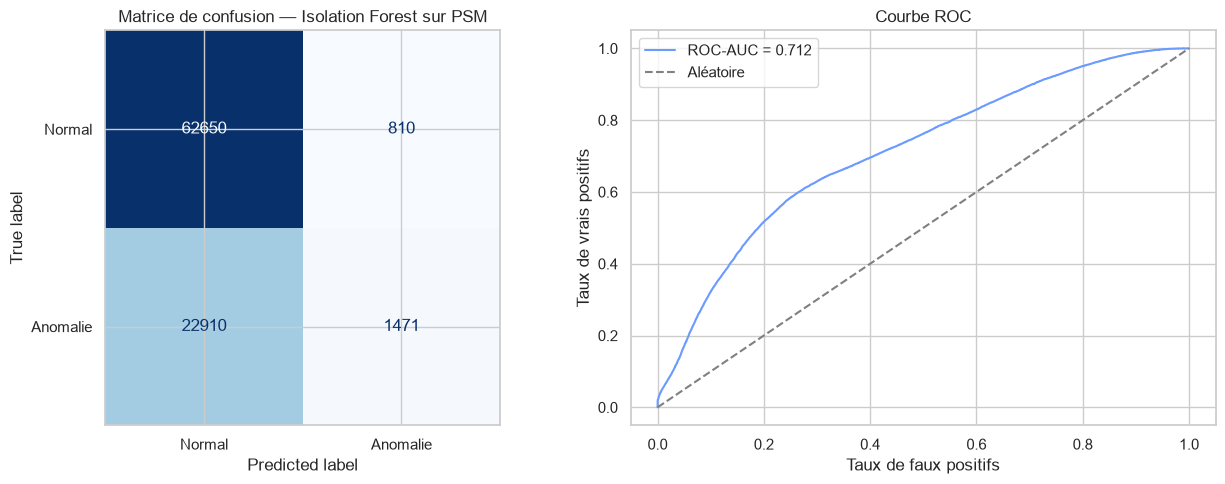

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomalie"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Matrice de confusion — Isolation Forest sur PSM")

fpr, tpr, _ = roc_curve(y_test, scores)
axes[1].plot(fpr, tpr, color="#6c9bff", label=f"ROC-AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aléatoire")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Comparaison de plusieurs valeurs de `contamination`

In [9]:
results = []
for c in [0.01, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.28, 0.30]:
    m = IsolationForest(n_estimators=100, contamination=c, random_state=42, n_jobs=-1)
    m.fit(X_train)
    pred = (m.predict(X_test) == -1).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, pred, average="binary", zero_division=0)
    results.append({"contamination": c, "precision": p, "recall": r, "f1": f})

results_df = pd.DataFrame(results)
results_df

,contamination,precision,recall,f1
0,0.01,1.000000,0.013945,0.027507
1,0.03,0.934164,0.021533,0.042096
2,0.05,0.644893,0.060334,0.110344
3,0.08,0.568241,0.161888,0.251987
4,0.10,0.565925,0.238013,0.335095
5,0.15,0.535320,0.377958,0.443082
6,0.20,0.505845,0.493376,0.499533
7,0.25,0.473055,0.583979,0.522697
8,0.28,0.450915,0.622452,0.522977
9,0.30,0.436553,0.645421,0.520827


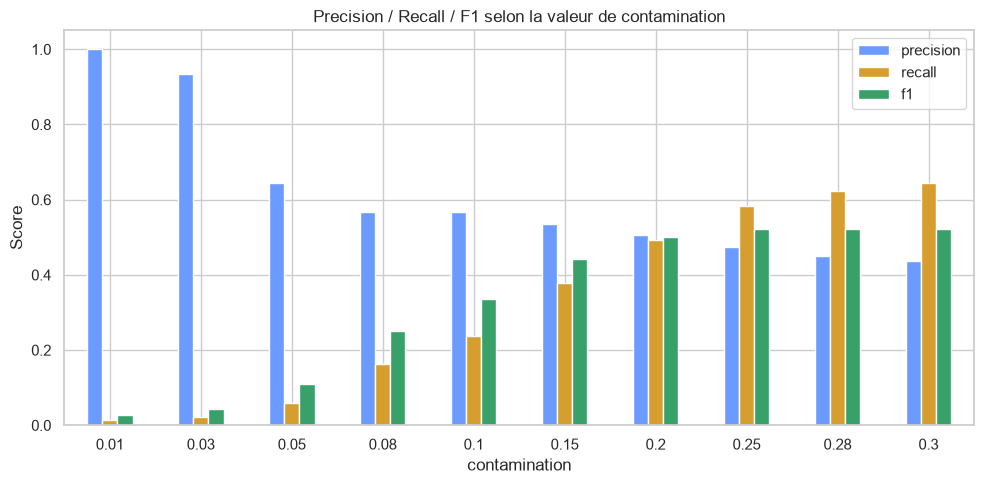

Meilleure valeur de contamination testée : 0.28 (F1 = 0.523)


In [10]:
ax = results_df.set_index("contamination")[["precision", "recall", "f1"]].plot(
    kind="bar", figsize=(10, 5), color=["#6c9bff", "#d69e2e", "#38a169"]
)
ax.set_title("Precision / Recall / F1 selon la valeur de contamination")
ax.set_ylabel("Score")
ax.set_xlabel("contamination")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df["f1"].idxmax()]
print(f"Meilleure valeur de contamination testée : {best_row['contamination']} (F1 = {best_row['f1']:.3f})")

## 6. Conclusion

In [11]:
print(f'''
Résumé de l'évaluation — Isolation Forest sur PSM (eBay, données réelles de production)
=========================================================================================
Taux d'anomalies réel observé dans test.csv : {anomaly_rate:.1%}

Configuration production (contamination=0.05, n_estimators=100) :
  - Precision            : {precision:.1%}
  - Recall                : {recall:.1%}
  - F1-score              : {f1:.1%}
  - Taux de faux positifs : {false_positive_rate:.1%}
  - ROC-AUC               : {roc_auc:.3f}

Meilleure configuration testée :
  - contamination = {best_row["contamination"]}  ->  F1 = {best_row["f1"]:.1%}
  (à comparer au taux d'anomalies réel de {anomaly_rate:.1%} : logique, contamination doit refléter la
  proportion réelle d'anomalies attendue dans les données pour bien calibrer le modèle)

Interprétation :
  L'Isolation Forest, entraîné uniquement sur du trafic serveur "normal" (train.csv), est capable de
  détecter les anomalies réelles du jeu de test avec un ROC-AUC de {roc_auc:.3f} (0.5 = hasard, 1.0 = parfait),
  ce qui démontre que le modèle capture un vrai signal de séparation normal/anormal indépendamment du seuil
  choisi. Avec contamination=0.05 (valeur par défaut du prediction-engine, pensée pour un environnement où
  les anomalies sont rares), le recall reste faible car le taux d'anomalies réel de PSM ({anomaly_rate:.1%})
  est bien plus élevé que 5%. Ceci illustre concrètement pourquoi la contamination doit être calibrée sur les
  données réelles de l'environnement cible plutôt que fixée arbitrairement — un point à documenter dans le
  rapport de stage comme piste d'amélioration du Prediction Engine.
''')


Résumé de l'évaluation — Isolation Forest sur PSM (eBay, données réelles de production)
Taux d'anomalies réel observé dans test.csv : 27.8%

Configuration production (contamination=0.05, n_estimators=100) :
  - Precision            : 64.5%
  - Recall                : 6.0%
  - F1-score              : 11.0%
  - Taux de faux positifs : 1.3%
  - ROC-AUC               : 0.712

Meilleure configuration testée :
  - contamination = 0.28  ->  F1 = 52.3%
  (à comparer au taux d'anomalies réel de 27.8% : logique, contamination doit refléter la
  proportion réelle d'anomalies attendue dans les données pour bien calibrer le modèle)

Interprétation :
  L'Isolation Forest, entraîné uniquement sur du trafic serveur "normal" (train.csv), est capable de
  détecter les anomalies réelles du jeu de test avec un ROC-AUC de 0.712 (0.5 = hasard, 1.0 = parfait),
  ce qui démontre que le modèle capture un vrai signal de séparation normal/anormal indépendamment du seuil
  choisi. Avec contamination=0.05 (valeur

---
**Note méthodologique** : cette évaluation utilise le schéma de features anonymisé propre à PSM
(`feature_0` .. `feature_24`). Le `prediction-engine` en production utilise un schéma de métriques
nommées et interprétables (`cpu_usage`, `memory_usage`, `disk_usage`, `network_in_mbps`,
`network_out_mbps`, `response_time_ms`, `error_rate`) adapté aux besoins du dashboard et du module RCA
(qui doit pouvoir dire *pourquoi* une anomalie a été détectée). Les deux modèles sont donc distincts :
celui-ci sert de preuve scientifique de la pertinence de l'algorithme sur des données réelles ; celui
utilisé par l'API en production reste entraîné/évalué séparément sur les métriques propres à la
plateforme BCT Supervision.